<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExbG04Y2Jycmk0aHpoaWV1cHZwbDc0M2l1em83MGJqYmd0YjB4cnhsdiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/eWdS9hpdeccG4/giphy.gif" alt="Beam Oscillation" width="400" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Implementation of the Fourier Pseudospectral 2D acoustic wave equation, in heterogneus medium</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Computers, Waves, Simulations: A Practical Introduction to Numerical Methods using Python</p>
  <p><b>Year:</b> MARCH - 2026</p>

</div>

### This notebook covers the following aspects:
* Present a  Fourier Pseudospectral code for solving the 2D acoustic wave equation


#### Basic Equations
This notebook presents a Fourier Pseudospectral code for solving the 2D acoustic wave equation.

The problem of solving the wave equation

\begin{equation}
\partial_t^2 p = c^2 (\partial_{x}^{2}p + \partial_{z}^{2}p) + s
\end{equation}

can be achieved using finite differeces in combination with spectral methods. Here, spatial partial derivatives with respect to $x$ and $z$ are computed via the Fourier method, i.e. 

\begin{equation}
\partial_{x}^{2}p + \partial_{z}^{2}p = \mathscr{F}^{-1}[-k_{x}^{2}\mathscr{F}[p]] + \mathscr{F}^{-1}[-k_{z}^{2}\mathscr{F}[p]]
\end{equation}

where $\mathscr{F}$ represents the Fourier transform operator.

### Libraries

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
from matplotlib.animation import FFMpegWriter
from IPython.display import display
import os
import pandas as pd
import importlib

In [2]:
from wave_propagation_2d import *

### Initial data:

In [ ]:
nx = 200                                                    # grid points in
nz = 200                                                    # grid points in
nt = 1000                                                   # number of time steps
xmax = 2000
esp = 0.2
dt = 0.001                                                  # Time step
c0 = 3000.0                                                 # velocity
isx = nx // 2                                               # source index
isz = nz // 3                                               # source index
ist = 100                                                   # shifting of source time function
f0 = 100.0                                                  # dominant frequency of source (Hz)
isnap = 10                                                  # snapshot frequency
T = 1.0 / f0                                                # dominant period
nop = 3                                                     # length of operator
redFac = 0.8                                                # Reduction factor for fault_zone
lenFaul = int(nx*0.1/4)                                     # Semi length of the fault_zone
fsc = 6.0                                                   # Scale for seismograph
idisp = 10
anim = 0                                                    # condition to show the animation, 1 = show
norder = 2

# -------------Model Type----------------------------
# model_type = "homogeneous"
# model_type = "fault_zone"
# model_type = "surface_low_velocity_zone"
# model_type = "random"
model_type = "topography"
# model_type = "slab"

# --------------Receiver locations-------------------
irx = np.array([30, 80, 100, 120, 140])
irz = np.array([5, 5, 5, 5, 5])
seis = np.zeros((len(irx), nt))

# Initialize pressure at different time steps and the second
# derivatives in each direction
p = np.zeros((nz, nx))
pold = np.zeros((nz, nx))
pnew = np.zeros((nz, nx))
pxx = np.zeros((nz, nx))
pzz = np.zeros((nz, nx))

In [4]:
dx = xmax / (nx-1)
dt = esp * dx / c0
print('Grid increment =', dx)
print('Time Step = ', dt, ' s')

Grid increment = 10.050251256281408
Time Step =  0.0006700167504187606  s


In [5]:
waveLen = c0 / f0
DivWave = waveLen / dx

print('Wave Length = ', waveLen, 'm')
print('Number of finite point per Wave Length = ', DivWave)

Wave Length =  30.0 m
Number of finite point per Wave Length =  2.985


#### Initialize velocity model

In [6]:
# Initialize velocity model (the fun bit!)
c = np.zeros((nz, nx))

if model_type == "homogeneous":
    c += c0

elif model_type == "fault_zone":
    c += c0
    c[:, nx // 2 - lenFaul: nx // 2 + lenFaul] *= redFac  

elif model_type == "surface_low_velocity_zone":
    c += c0
    c[1:10,:] *= 0.8

elif model_type == "random":
    pert = 0.4
    r = 2.0 * (np.random.rand(nz, nx) - 0.5) * pert
    c += c0 * (1 + r)   

elif model_type == "topography":
    c += c0
    c[0 : 10, 10 : 50] = 600                         
    c[0 : 10, 105 : 115] = 1300                       
    c[0 : 30, 145 : 170] = 800
    c[10 : 40, 20 : 40]  = 1000
    c[0 : 15, 50 : 105] *= 0.8   

elif model_type == "slab":

    c += c0

    c[90 : 100, 0 : 200] = 0.6 * c0

    c[100 : 110, 0 : 125] = 1.3 * c0
    for i in range(100, 180):
        c[i , i-5 : i + 200 ] = 1.3 * c0

    c[110 : 125, 0 : 125] = 1.4 * c0
    for i in range(110, 180):
        c[i , i-5 : i + 15 ] = 1.4 * c0
    
else:
    raise NotImplementedError
    
cmax = c.max()

print('Maximum velocity = ', cmax)

Maximum velocity =  4200.0


In [7]:
c_df = pd.DataFrame(c)
c_df.head(len(c_df))

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
1,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
2,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
3,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
4,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
196,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
197,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
198,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,...,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0


#### Initializing Source time function Gaussian

In [8]:
# Source time function Gaussian, nt + 1 as we loose the last one by diff
src_g = np.empty(nt + 1)
for it in range(nt):
    src_g[it] = np.exp(-1.0 / T ** 2 * ((it - ist) * dt) ** 2)
# Take the first derivative
src = np.diff(src_g) / dt
src[nt - 1] = 0

time = np.linspace(0, dt, nt)

src_df = pd.DataFrame(np.column_stack((time, src)), columns=['Time [s]', 'Amplitude'])
src_df.head(len(src_df))



,Time [s],Amplitude
0,0.000000e+00,6.867858e-17
1,6.706874e-07,1.652643e-16
2,1.341375e-06,3.940903e-16
3,2.012062e-06,9.312584e-16
4,2.682750e-06,2.180728e-15
...,...,...
995,6.673340e-04,0.000000e+00
996,6.680047e-04,0.000000e+00
997,6.686754e-04,0.000000e+00
998,6.693461e-04,0.000000e+00


### Source Function

,Frequencies,Amplitudes
0,1.4925,0.000000e+00
1,2.9850,2.475301e+02
2,4.4775,4.918033e+02
3,5.9700,7.296341e+02
4,7.4625,9.579773e+02
...,...,...
494,738.7875,6.294146e-13
495,740.2800,5.657201e-13
496,741.7725,6.632008e-13
497,743.2650,6.104683e-13


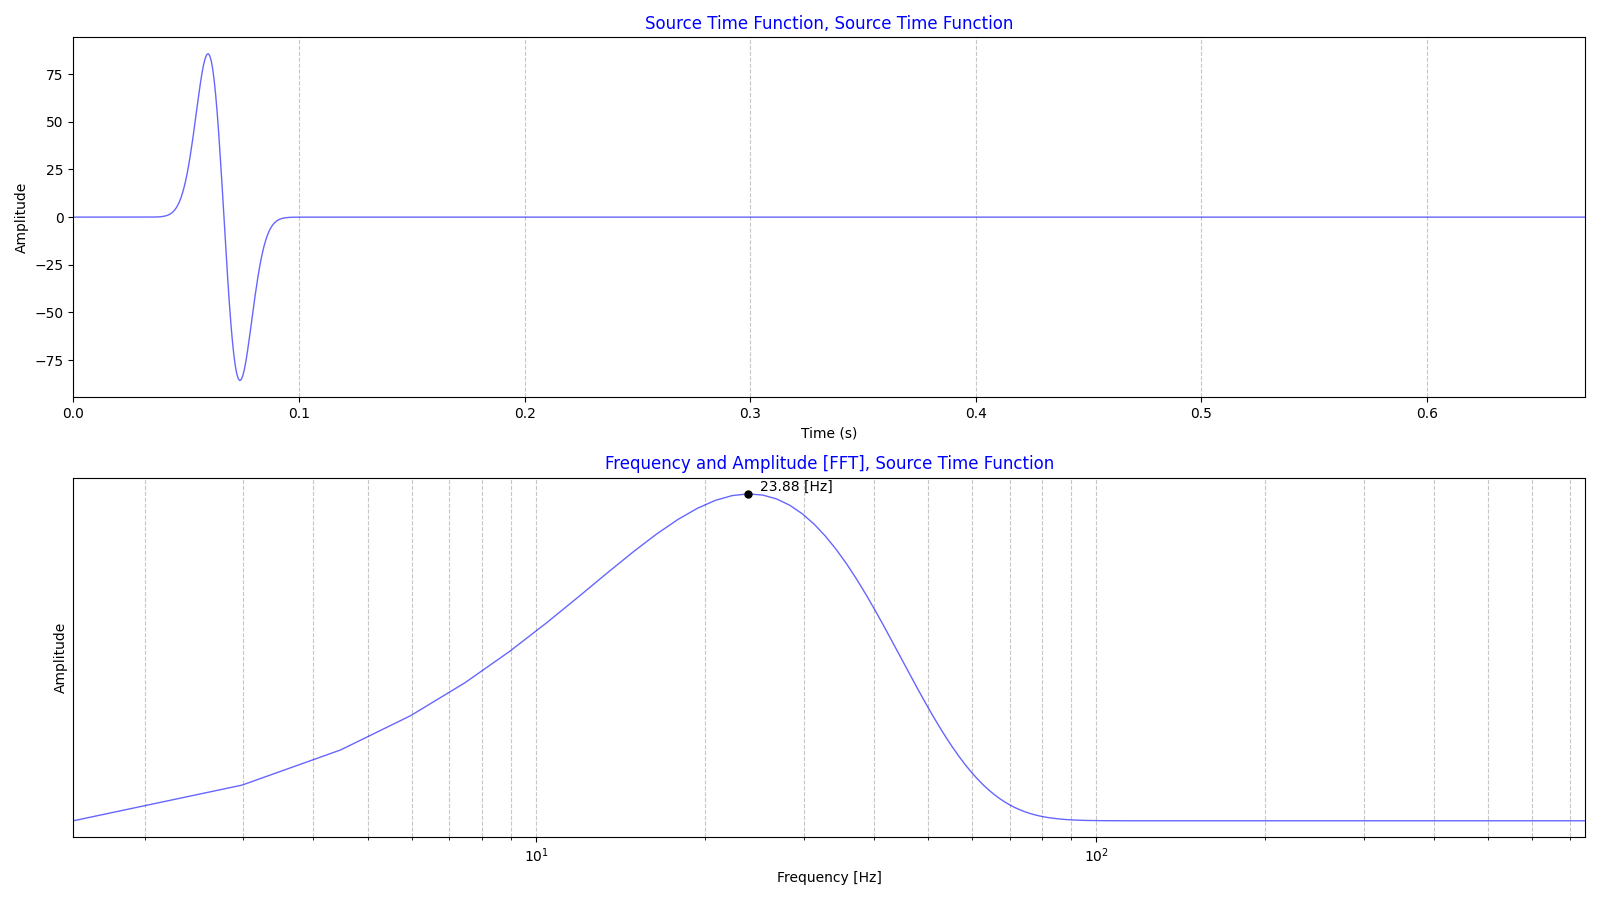

In [9]:
FFtsrc = FFt_src(src, dt, nt, record = 'Source Time Function')
frequencies, fft, RESULT = FFtsrc.fft_src()
RESULT.head(len(RESULT))

### Finite Diffesrence Method

Courant Criterion eps :
0.28


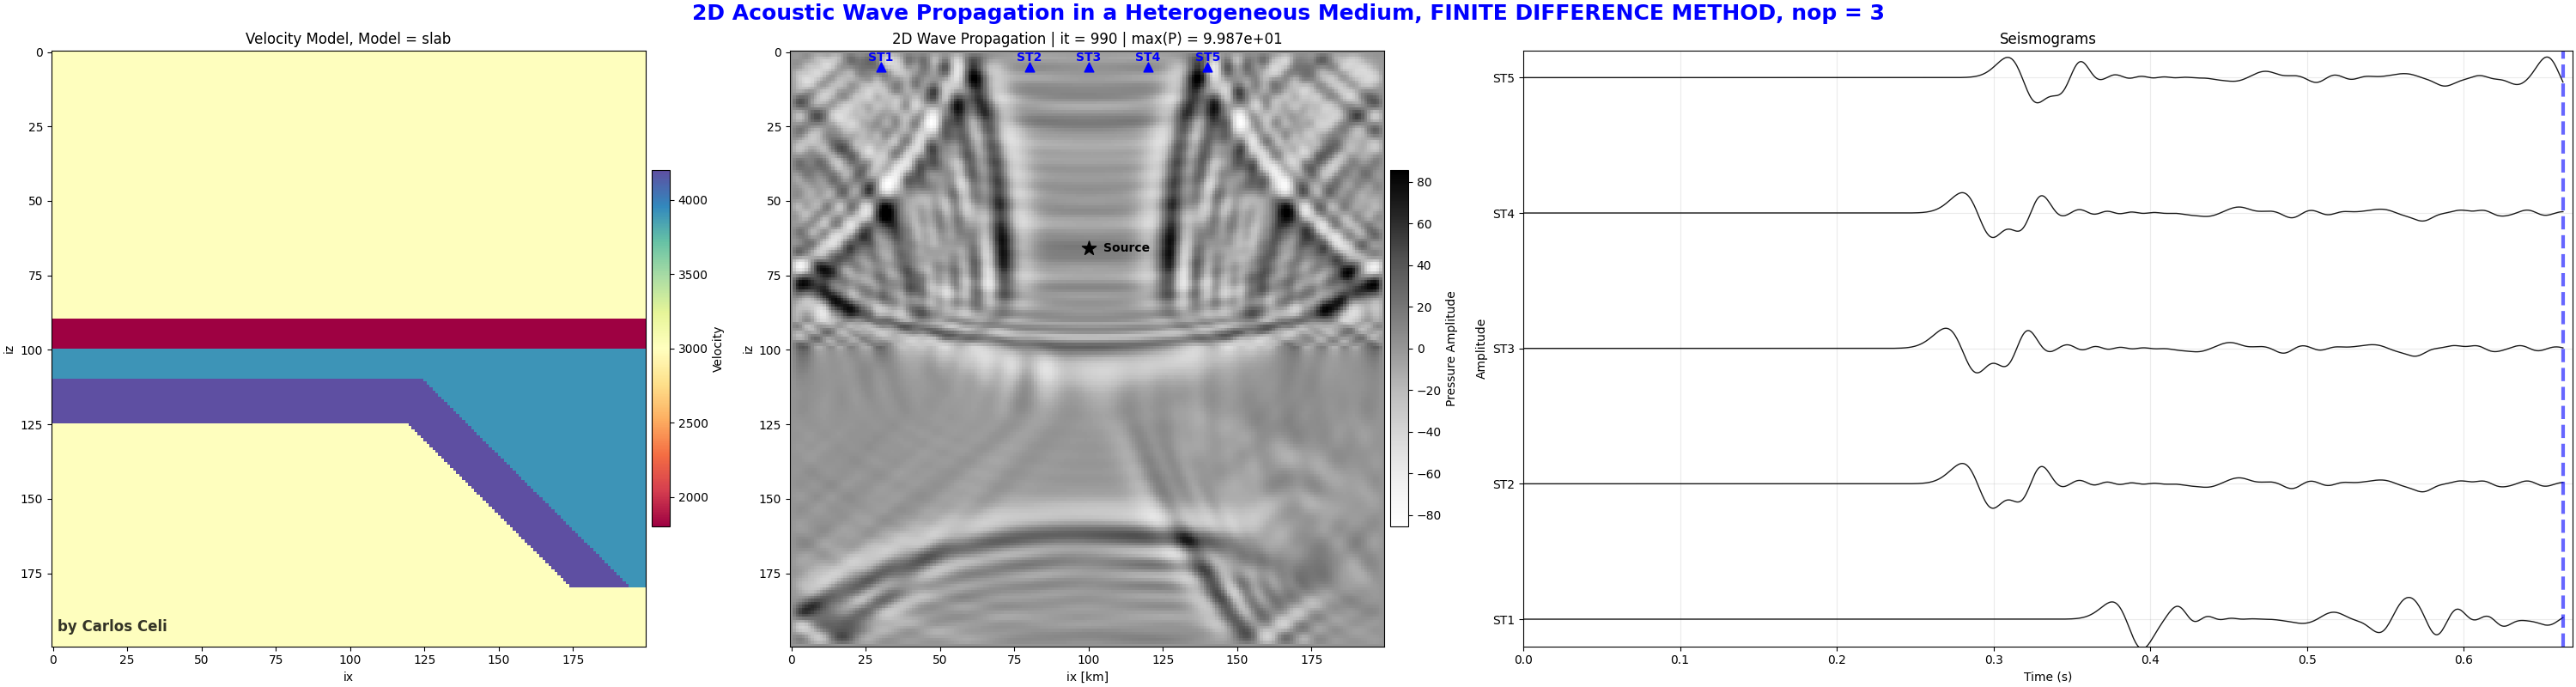

In [10]:
if anim == 1:
    anim2d_FDM = animation2D_FDM(
        nx, nz, dx, dt, nt,
        model_type, c, isx, isz, irx, irz, src,
        idisp=idisp,
        nop=nop,
        fsc=fsc,
        cmap=plt.cm.Grays,
        show=True,
        save=False
    )
    seis = anim2d_FDM.animate()
else:
    anim2d_FDM = animation2D_FDM(
        nx, nz, dx, dt, nt,
        model_type, c, isx, isz, irx, irz, src,
        idisp=idisp,
        nop=nop,
        fsc=fsc,
        cmap=plt.cm.Grays,
        show=False,
        save=True
    )
    seis = anim2d_FDM.animate()

### Pseudo Spectral Method

Courant Criterion eps :
0.28


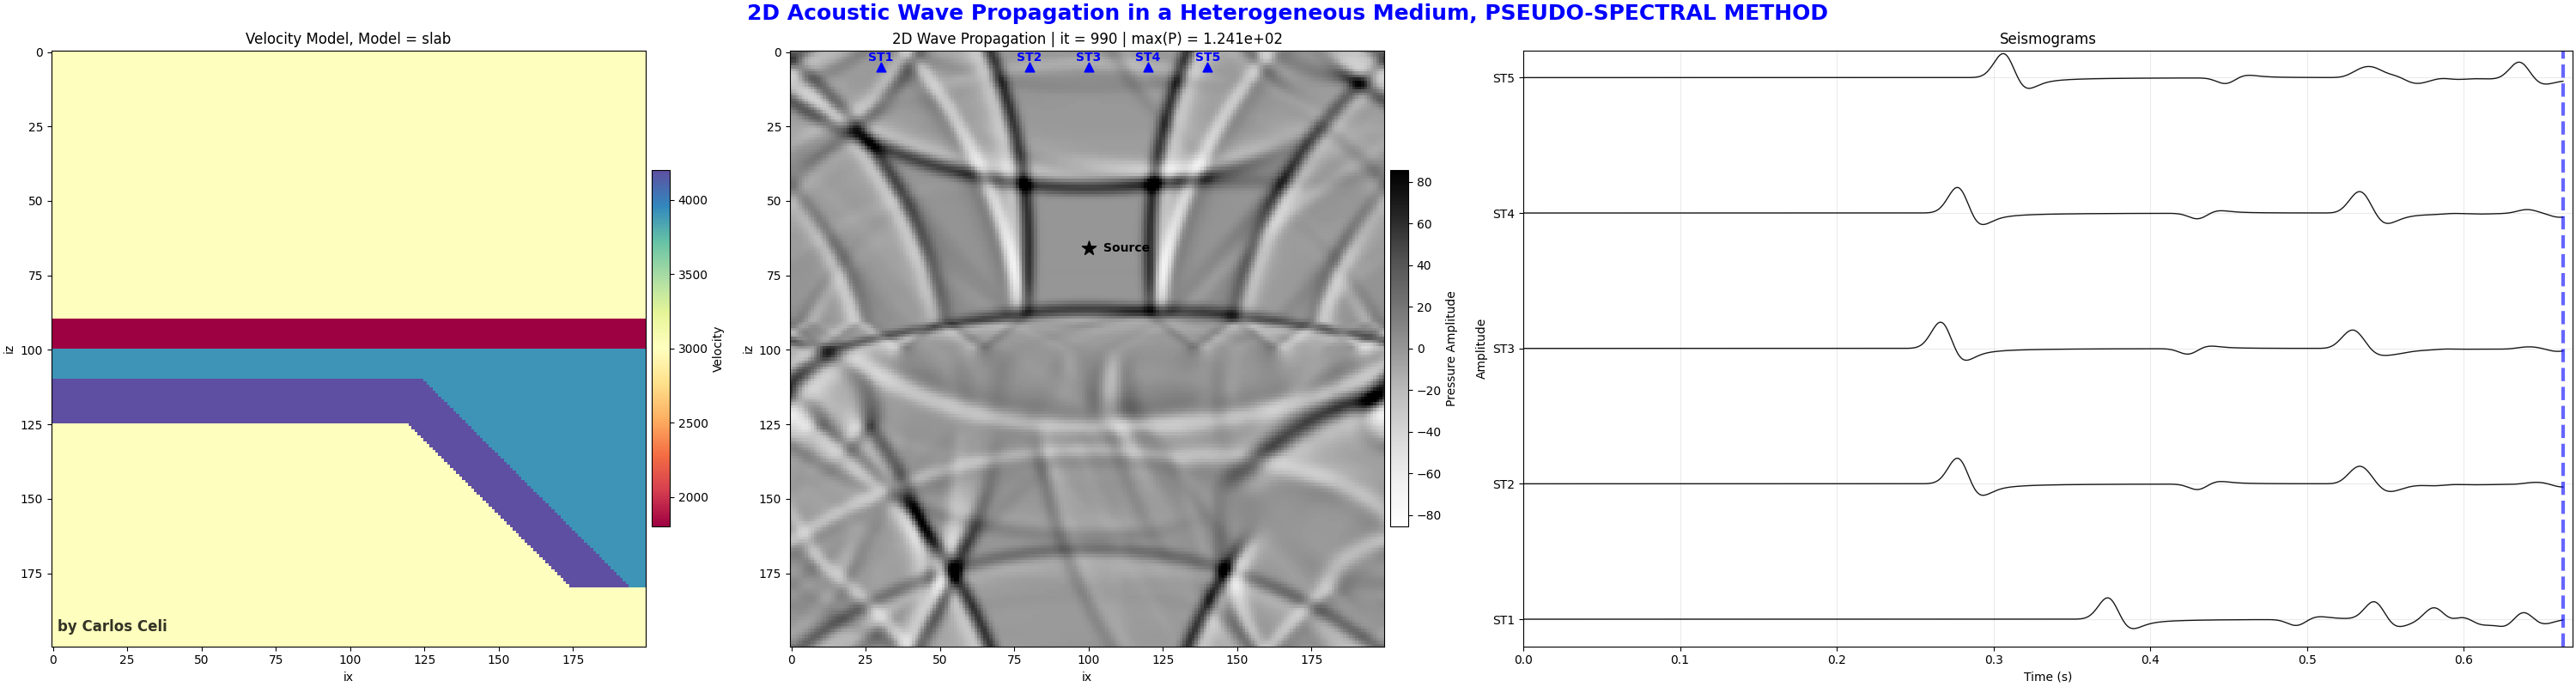

In [11]:
if anim == 1:
    anim2d_SeuSepc = animation2D_PeudoSpectral(
        nx, nz, dx, dt, nt,
        model_type, c, isx, isz, irx, irz, src, norder,
        idisp=idisp,
        fsc=fsc,
        cmap=plt.cm.Grays,
        show=True,
        save=False
    )
    seis = anim2d_SeuSepc.animate_PseudoSpectral()
else:
    anim2d_SeuSepc = animation2D_PeudoSpectral(
        nx, nz, dx, dt, nt,
        model_type, c, isx, isz, irx, irz, src, norder,
        idisp=idisp,
        fsc=fsc,
        cmap=plt.cm.Grays,
        show=False,
        save=True
    )
    seis = anim2d_SeuSepc.animate_PseudoSpectral()